## NVDA Time Series – Main Notebook

This notebook replaces the previous `main.py` script as the primary interactive entry point for the NVDA projects.

Use it to:
- Download and load the NVDA dataset.
- Run preprocessing and basic data description.
- Inspect the DataFrame with commands like `df.head()`.
- Later: perform transformations to returns and add visualizations (after we verify the time-series structure).


In [93]:
#!pip install numpy pandas matplotlib seaborn statsmodels scikit-learn yfinance jupyter

In [94]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller


from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import randint, uniform

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Data import and cleaning

In [95]:
df = yf.download(
    tickers="NVDA",
    start="2021-01-01",
    end="2026-03-05",
    auto_adjust=True,
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index = pd.to_datetime(df.index)
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(1297, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,13.076018,13.613478,12.925450,13.066795,560640000
2021-01-05,13.366435,13.405074,13.049593,13.062307,322760000
2021-01-06,12.578444,13.207142,12.550026,13.184706,580424000
2021-01-07,13.305860,13.339514,12.849668,12.930436,461480000
2021-01-08,13.238801,13.382639,13.004722,13.324306,292528000


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 1 — Data Download</strong></summary>
        <ul>
            <li>NVIDIA stock data (<code>NVDA</code>) was downloaded using the <code>yfinance</code> library covering the period <strong>January 2021 – March 2026</strong>, providing approximately five years of daily trading data.</li>
            <li>The <code>auto_adjust=True</code> parameter ensures prices are adjusted for stock splits and dividends — important for NVIDIA given its <strong>10-for-1 stock split in June 2024</strong>, which would otherwise create an artificial price discontinuity.</li>
            <li>The date range was chosen to capture both the pre-AI-boom period (2021–2022) and the high-growth AI-driven period (2023–2026), providing structural diversity in the data.</li>
        </ul>
    </details>
</div>

In [96]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df.index.min(), "→", df.index.max())
df.describe()

Shape: (1297, 5)

Dtypes:
 Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Date range: 2021-01-04 00:00:00 → 2026-03-04 00:00:00


Price,Close,High,Low,Open,Volume
count,1297.000000,1297.000000,1297.000000,1297.000000,1.297000e+03
mean,71.034968,72.237545,69.732909,71.058949,3.879523e+08
std,60.321858,61.227197,59.399358,60.416649,1.846455e+08
min,11.212297,11.719631,10.798839,10.956632,6.552850e+07
25%,19.617062,19.983222,19.206003,19.640009,2.313979e+08
50%,42.963421,43.580934,42.101086,42.718129,3.713890e+08
75%,123.990829,126.439034,120.971669,123.739454,5.011480e+08
max,207.017273,212.166717,205.537422,208.057150,1.543911e+09


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 2 — Data Inspection</strong></summary>
        <ul>
            <li>Raw data was inspected for shape, data types, and missing values before any modifications — standard practice to understand what cleaning steps are actually necessary rather than applying them blindly.</li>
            <li>The dataset contains five OHLCV columns: <code>Open</code>, <code>High</code>, <code>Low</code>, <code>Close</code>, <code>Volume</code>. Since <code>auto_adjust=True</code> was used, prices are already adjusted and no separate <code>Adj Close</code> column appears.</li>
            <li>The index is a <code>DatetimeIndex</code> at daily frequency, covering only trading days — weekends and public holidays are naturally absent, which is expected behavior for financial data.</li>
        </ul>
    </details>
</div>

In [97]:
df = df[~df.index.duplicated(keep="first")]

df = df.dropna(subset=["Close"])

df = df.ffill()

print("Shape after cleaning:", df.shape)
print("Missing values:\n", df.isnull().sum())

Shape after cleaning: (1297, 5)
Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 3 — Data Cleaning</strong></summary>
        <ul>
            <li>Duplicate index rows were removed using <code>df.index.duplicated(keep="first")</code> — rare in yfinance data but possible if API calls overlap on boundary dates.</li>
            <li>Rows where <code>Close</code> is missing were dropped first, since <code>Close</code> is the foundation for all derived features and the target variable — any row without it is unusable.</li>
            <li>Remaining gaps were forward-filled using <code>ffill()</code>, which carries the last known value forward. This is preferred over mean imputation for time series because it respects temporal order and does not introduce future information.</li>
            <li>After cleaning, missing value counts were confirmed to be zero across all columns before proceeding to feature engineering.</li>
        </ul>
    </details>
</div>

# Feature Engineering

In [98]:
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

In [99]:
df["Lag_1"] = df["Log_Return"].shift(1)
df["Lag_2"] = df["Log_Return"].shift(2)
df["Lag_5"] = df["Log_Return"].shift(5)

In [100]:
df["Volatility_10"] = df["Log_Return"].rolling(window=10).std()
df["Volatility_20"] = df["Log_Return"].rolling(window=20).std()

In [101]:
rolling_mean = df["Close"].rolling(window=20).mean()
rolling_std  = df["Close"].rolling(window=20).std()
bb_upper     = rolling_mean + (2 * rolling_std)
bb_lower     = rolling_mean - (2 * rolling_std)
bb_width     = bb_upper - bb_lower

df["BB_Pct"] = (df["Close"] - bb_lower) / bb_width

In [102]:
df["Volume_Change"] = df["Volume"].pct_change()

In [103]:
sp500 = yf.download("^GSPC", start="2021-01-01", end="2026-03-05", auto_adjust=True)["Close"].squeeze()
vix   = yf.download("^VIX",  start="2021-01-01", end="2026-03-05", auto_adjust=True)["Close"].squeeze()

df["SP500_Return"] = np.log(sp500 / sp500.shift(1))
df["VIX"] = vix

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [104]:
df["Target"] = df["Log_Return"].shift(-1)

In [105]:
df = df.dropna()

print("Final shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Final shape: (1276, 16)
Missing values:
 Price
Close            0
High             0
Low              0
Open             0
Volume           0
Log_Return       0
Lag_1            0
Lag_2            0
Lag_5            0
Volatility_10    0
Volatility_20    0
BB_Pct           0
Volume_Change    0
SP500_Return     0
VIX              0
Target           0
dtype: int64


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 4 — Feature Engineering</strong></summary>
        <ul>
            <li>Raw OHLCV data alone provides insufficient regressors for a meaningful regression task — feature engineering expands the input space from 5 raw columns to <strong>10 economically motivated features</strong>.</li>
            <li><strong>Log returns</strong> (<code>Log_Return</code>) are computed as <code>ln(Close_t / Close_{t-1})</code> rather than simple percentage returns — they are approximately normally distributed, time-additive, and stationary, making them the standard choice in financial modelling.</li>
            <li><strong>Lagged returns</strong> (<code>Lag_1</code>, <code>Lag_2</code>, <code>Lag_5</code>) frame the problem as a supervised learning task — past returns become predictors of the next day's return, consistent with autoregressive modelling logic.</li>
            <li><strong>Rolling volatility</strong> (<code>Volatility_10</code>, <code>Volatility_20</code>) captures short-term and medium-term volatility regimes respectively. Both were retained despite correlation, as they represent distinct time horizons and provide interpretable contrast in the coefficient plots.</li>
            <li><strong>Bollinger Band %</strong> (<code>BB_Pct</code>) measures where the current price sits within its 20-day band — bounded approximately between 0 and 1, stationary, and more informative than raw moving averages which are non-stationary.</li>
            <li><strong>Volume Change</strong> captures relative day-over-day trading activity, which can signal institutional interest or panic selling independent of price direction.</li>
            <li><strong>External regressors</strong> (<code>SP500_Return</code>, <code>VIX</code>) introduce market-wide context. S&P 500 log returns represent systematic market risk, while VIX is a forward-looking fear gauge — conceptually distinct from the backward-looking realized volatility features already included.</li>
            <li>The <strong>target variable</strong> is defined as the next day's log return (<code>Log_Return.shift(-1)</code>), ensuring no same-day information is used to predict same-day outcomes — a common source of feature leakage in stock prediction tasks that was explicitly avoided here.</li>
        </ul>
    </details>
</div>

# EDA

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Log Returns Instead of Simple Returns</strong></summary>
        <ul>
            <li><strong>Simple returns</strong> are computed as <code>(P_t - P_{t-1}) / P_{t-1}</code>. While intuitive, they are asymmetric — a 50% loss requires a 100% gain to recover, which creates a mathematical inconsistency when aggregating returns over time.</li>
            <li><strong>Log returns</strong> are computed as <code>ln(P_t / P_{t-1})</code>. They are <strong>time-additive</strong>, a multi-period log return is simply the sum of single-period log returns, which makes them mathematically convenient for regression and statistical testing.</li>
            <li><strong>Stationarity:</strong> Raw closing prices are non-stationary (confirmed visually by the upward trend in the price plot and formally by the ADF test). Log returns remove this trend and produce a stationary series centered near zero, which is a fundamental requirement for regression modelling.</li>
            <li><strong>Approximate normality:</strong> Log returns are approximately normally distributed for short intervals, which aligns with the assumptions of linear regression. Simple returns are bounded below by -100% but unbounded above, making their distribution right-skewed and less well-behaved statistically.</li>
            <li><strong>Variance stabilization:</strong> Taking the logarithm compresses large price movements proportionally, reducing the influence of extreme values. A move from $100 to $200 and a move from $500 to $1000 both produce a log return of ~0.693, correctly treating them as equivalent in relative terms.</li>
            <li>For these reasons, log returns are used in <strong> in finance and time series</strong> for regression, time series modelling, and risk analysis.</li>
        </ul>
    </details>
</div>

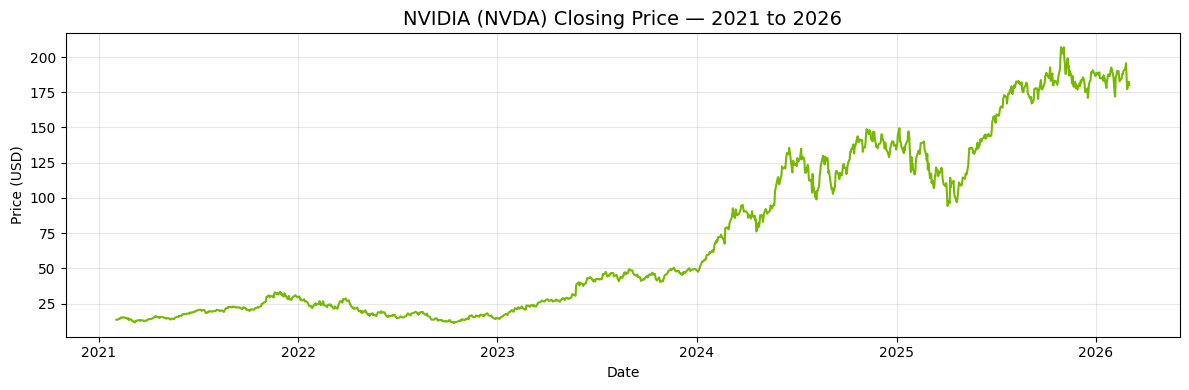

In [106]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["Close"], color="#76b900", linewidth=1.5)  

ax.set_title("NVIDIA (NVDA) Closing Price — 2021 to 2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

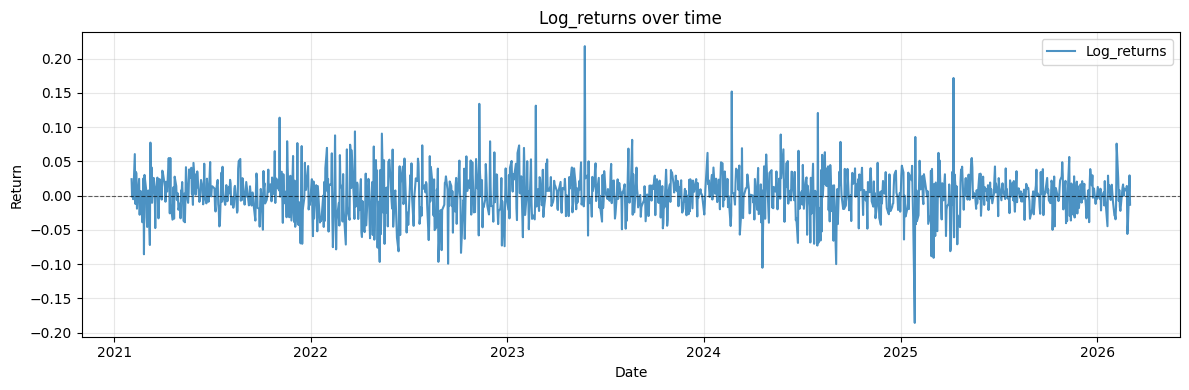

In [107]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df["Log_Return"], label="Log_returns", alpha=0.8)

plt.title("Log_returns over time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

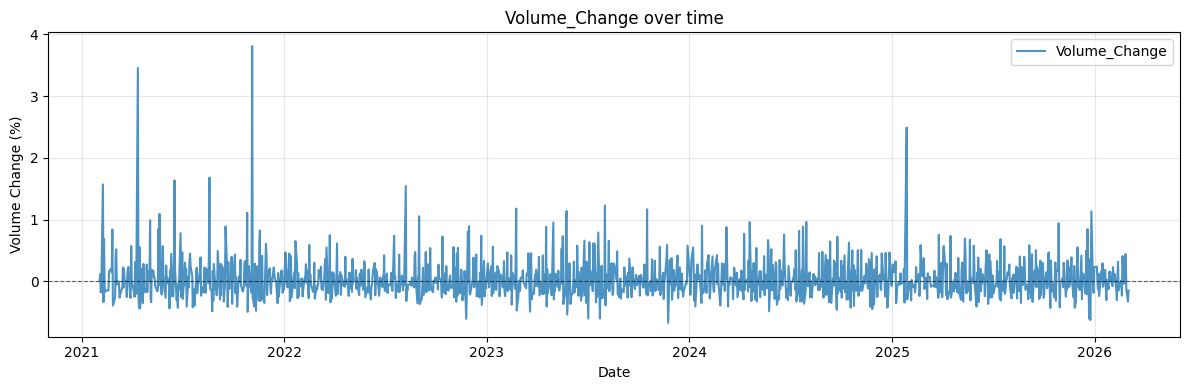

In [108]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df["Volume_Change"], label="Volume_Change", alpha=0.8)

plt.title("Volume_Change over time")
plt.xlabel("Date")
plt.ylabel("Volume Change (%)")
plt.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
df["Volume"].sort_values(ascending=False).head()

Date
2023-05-25    1543911000
2022-09-01    1178865000
2023-08-24    1156044000
2021-11-04    1153631000
2024-03-08    1142269000
Name: Volume, dtype: int64

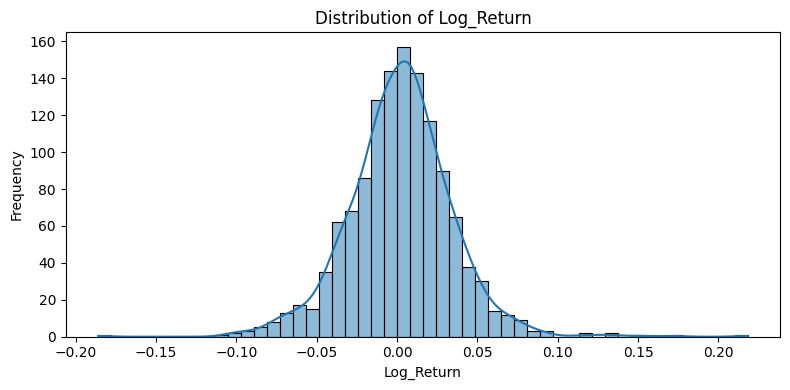

In [110]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Log_Return"], bins=50, kde=True)

plt.xlabel("Log_Return")
plt.ylabel("Frequency")
plt.title(f"Distribution of {"Log_Return"}")
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Distribution of Log Returns — Interpretation</strong></summary>
        <li>The <strong>distribution of log returns</strong> is approximately bell-shaped and centred near zero, consistent with stationarity. However, the distribution exhibits <strong>fat tails</strong> (excess kurtosis) — extreme returns occur more frequently than a normal distribution would predict, a well-documented feature of financial data.</li>
    </details>
</div>

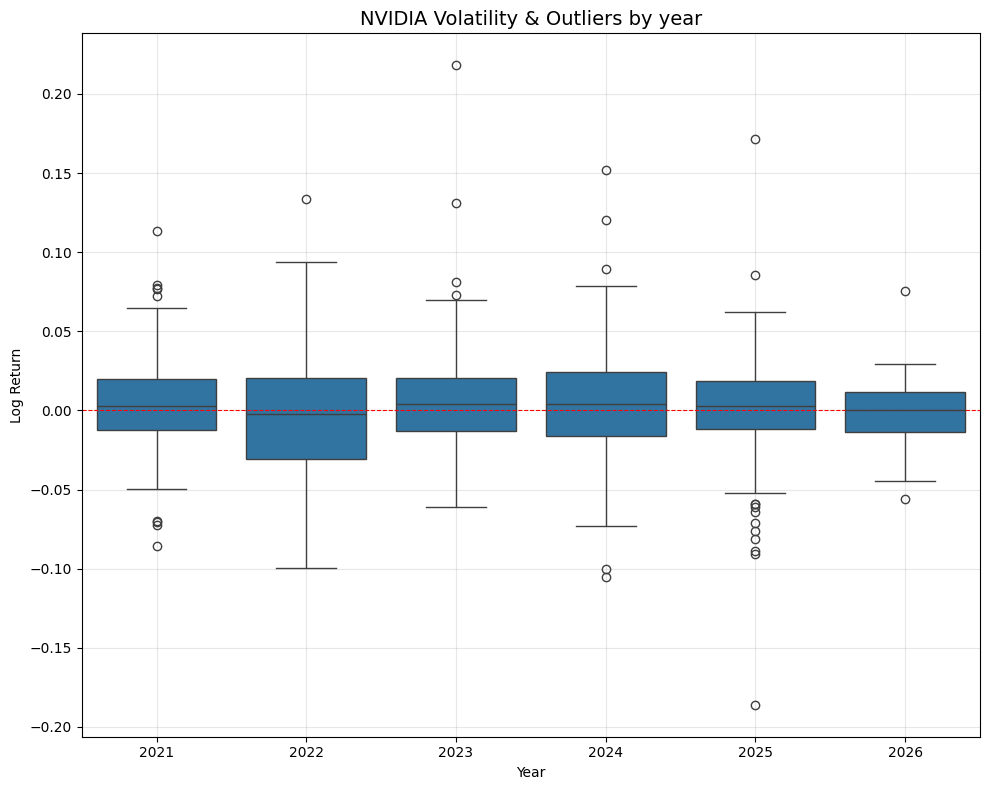

In [134]:
fig, ax = plt.subplots(figsize=(10, 8))

df_box = df[["Log_Return"]].copy()
df_box["Year"] = df.index.year

sns.boxplot(data=df_box, x="Year", y="Log_Return", ax=ax)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")

ax.set_title("NVIDIA Volatility & Outliers by year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Log Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Boxplot of Log Returns by Year</strong></summary>
        <p>The boxplot shows visibly wider interquartile ranges and more extreme outliers in 2023–2025 compared to 2021–2022, reflecting heightened volatility during the AI boom. This year-on-year variation directly motivates the inclusion of <code>Volatility_10</code> and <code>Volatility_20</code> as features in the model.</p>
    </details>
</div>

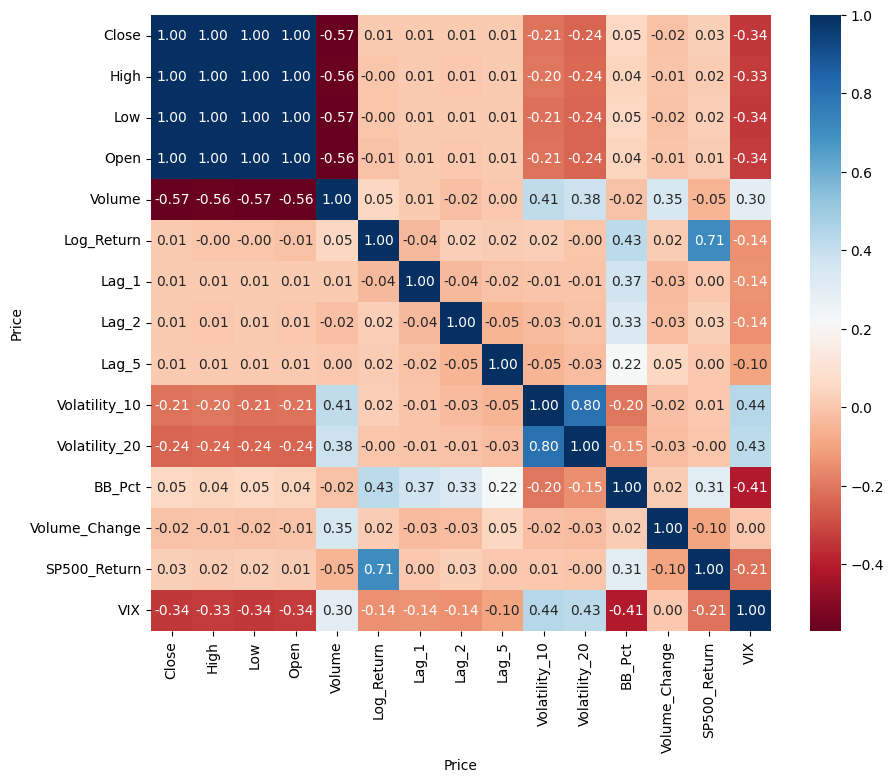

In [112]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.drop(columns=["Target"]).corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu")
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 5 — Exploratory Data Analysis (EDA)</strong></summary>
        <ul>
            <li>EDA was conducted after cleaning but before modelling.</li>
            <li>The <strong>closing price line plot</strong> reveals a clear structural break around late 2022 / early 2023, coinciding with the surge in AI investment following ChatGPT's release NVIDIA's exponential price appreciation from this point confirms that raw price levels are non-stationary and unsuitable as regression targets.</li>
            <li>The <strong>log returns line plot</strong> shows volatility clustering, periods of large swings followed by relative calm, characteristic of financial return series and the motivation behind ARCH/GARCH models in econometrics.</li>
            <li>The <strong>correlation heatmap</strong> confirms moderate correlation between <code>Volatility_10</code> and <code>Volatility_20</code>, and between the three lag features, Ridge Regression handles multicollinearity through L2 regularization.</li>
        </ul>
    </details>
</div>

# ADF Test Staionarity

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>ADF Test</strong></summary>
        <p>Before fitting any regression model, we must verify that our time series features are <strong>stationary</strong>, their statistical properties (mean, variance) do not change over time. Using non-stationary features in regression can produce <strong>spurious relationships</strong>, where variables appear correlated simply because they share a common trend rather than a genuine predictive connection. The <strong>Augmented Dickey-Fuller (ADF) test</strong> formally tests for the presence of a unit root (non-stationarity), and passing it on all three series — NVDA log returns, S&P 500 log returns, and VIX — confirms the feature set is statistically appropriate for regression modelling without further transformation.</p>
    </details>
</div>

In [113]:
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval, lags, nobs, crit, _ = result

    print(f"{name}")
    print(f"ADF Statistic: {stat:.4f}")
    print(f"p-value: {pval:.4f}")
    print(f"Used lags: {lags}")
    
    for k, v in crit.items():
        print(f"Critical Value ({k}): {v:.4f}")

    if pval < 0.05:
        print("Stationary (reject H0)")
    else:
        print("Non-stationary (fail to reject H0)")
    
    print()

In [114]:
run_adf(df["Log_Return"], "NVIDIA Log Returns")

run_adf(df["VIX"], "VIX (level series)")

run_adf(df["SP500_Return"], "S&P 500 Log Returns")

NVIDIA Log Returns
ADF Statistic: -21.6025
p-value: 0.0000
Used lags: 2
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)

VIX (level series)
ADF Statistic: -4.9555
p-value: 0.0000
Used lags: 4
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)

S&P 500 Log Returns
ADF Statistic: -22.2530
p-value: 0.0000
Used lags: 2
Critical Value (1%): -3.4355
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Stationary (reject H0)



<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 6 — Stationarity Testing (ADF)</strong></summary>
        <ul>
            <li>The <strong>Augmented Dickey-Fuller (ADF) test</strong> was applied to verify stationarity before modelling — a requirement for regression on time series data, as non-stationary features can produce spurious relationships.</li>
            <li>The null hypothesis is the presence of a unit root (non-stationarity). Rejection at the 5% significance level confirms the series is stationary and safe to use as a feature or target.</li>
            <li><strong>NVDA Log Return</strong> — null hypothesis rejected (p &lt; 0.05). Daily log returns are stationary, validating the use of <code>Log_Return</code> and its lags as both features and the target variable.</li>
            <li><strong>S&P 500 Log Return</strong> — null hypothesis rejected (p &lt; 0.05). Stationary, consistent with efficient market theory that aggregate market returns are not predictable from their own history.</li>
            <li><strong>VIX (level series)</strong> — null hypothesis rejected (p &lt; 0.05). Although VIX is a level series rather than a return, its strong mean-reverting properties result in stationarity — no transformation was required.</li>
            <li>All three series passed the stationarity check, confirming the feature set is appropriate for regression modelling without further differencing.</li>
        </ul>
    </details>
</div>

# Preprocessing

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong> Train Test Split</strong></summary>
        <p>Unlike standard tabular data where observations are independent, time series data is <strong>ordered</strong>, future values depend on past ones, so randomly shuffling and splitting would allow the model to train on future data and test on the past, a critical error known as <strong>look-ahead bias</strong>. To replicate a realistic forecasting scenario, the data was split chronologically at the 80% mark, with the training set covering February 2021 – February 2025 and the test set covering February 2025 – March 2026. The same logic applies to cross-validation during hyperparameter tuning, where <code>TimeSeriesSplit</code> was used instead of standard <code>KFold</code> to ensure each validation fold always lies strictly in the future relative to its training fold.</p>
    </details>
</div>

In [115]:
split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

features = ["Lag_1", "Lag_2", "Lag_5", "Volatility_10", "Volatility_20", "BB_Pct", "Volume_Change", "SP500_Return", "VIX"]

X_train = train[features]
y_train = train["Target"]

X_test  = test[features]
y_test  = test["Target"]

print(f"Training set: {X_train.shape[0]} observations  ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Testing set: {X_test.shape[0]}  observations  ({test.index[0].date()} to {test.index[-1].date()})")

Training set: 1020 observations  (2021-02-02 to 2025-02-24)
Testing set: 256  observations  (2025-02-25 to 2026-03-03)


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Scale Features Before Modelling</strong></summary>
        <p>Linear and Ridge Regression are sensitive to the scale of input features — a feature with values in the thousands (e.g. raw volume) would dominate the coefficient estimates over a feature bounded between 0 and 1 (e.g. <code>BB_Pct</code>), regardless of their actual predictive importance. <code>StandardScaler</code> transforms each feature to have <strong>zero mean and unit variance</strong>, ensuring all features contribute on equal footing and that Ridge's L2 penalty is applied fairly across all coefficients. The scaler was fitted <strong>exclusively on the training set</strong>.
    </details>
</div>

In [116]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 

# Modelling

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Section 7 — Model Selection & Hyperparameter Tuning</strong></summary>
        <ul>
            <li>Four models were selected to represent a natural progression of complexity: <strong>Linear Regression</strong> (acs as a baseline) → <strong>Ridge Regression</strong> (regularized linear), then <strong>Random Forest</strong> (nonlinear, tree-based), then <strong>Gradient Boosting</strong> (sequential ensemble).</li>
            <li><strong>Linear Regression</strong> has no hyperparameters and was fitted directly. <strong>Ridge</strong>'s single parameter <code>alpha</code> was selected via cross-validated MAE across candidates [0.01, 0.1, 1.0, 10, 100] — the optimal value of <strong>α=100</strong> indicates strong regularization, consistent with the moderate multicollinearity observed in the feature heatmap.</li>
            <li><strong>Random Forest and Gradient Boosting</strong> were tuned using <code>RandomizedSearchCV</code> with <code>TimeSeriesSplit(n_splits=5)</code>. Standard <code>KFold</code> was deliberately avoided — it shuffles observations randomly, which would leak future data into training folds and invalidate temporal integrity.</li>
            <li>A <strong>two-grid tuning strategy</strong> was applied: Grid 1 used wide boundaries to explore the parameter space; Grid 2 narrowed the search around Grid 1's best values with increased <code>n_iter=50</code>. A third grid was considered but omitted as improvement from Grid 1 to Grid 2 was already marginal, indicating convergence.</li>
            <li>All hyperparameter selection was performed <strong>exclusively on training data</strong>. The test set was never evaluated during tuning.</li>
            <li>Feature scaling via <code>StandardScaler</code> was applied to Linear and Ridge models only. The scaler was fitted on training data and applied to the test set, preventing distribution leakage. Tree-based models are do not require scaling and received raw features directly.</li>
        </ul>
    </details>
</div>

In [117]:
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    print(f"{name}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²: {r2:.4f}")
    print()
    
    return {"Model": name, "MAE": round(mae, 6), "RMSE": round(rmse, 6), "R²": round(r2, 4)}

results = []

## Hyperparamter Tuning with RandomizedSeachCV

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Hyperparameter Grids with RandomizedSearchCV</strong></summary>
        <p>Rather than manually guessing hyperparameters, <code>RandomizedSearchCV</code> systematically samples random combinations from predefined parameter grids and evaluates each using cross-validation, selecting the combination that minimizes MAE on the training data. A two-grid strategy was applied — Grid 1 deliberately wide to explore the full parameter space, Grid 2 narrowed around Grid 1's best values with more iterations.</p>
    </details>
</div>

In [118]:
SEED = 42

In [119]:
tscv = TimeSeriesSplit(n_splits=5)


def run_randomized_search(estimator, param_grid, name, X, y, cv_strategy, n_iter=30):
    """
    Executes a RandomizedSearchCV, fits the data, and prints the best parameters and MAE.
    Returns the fitted search object.
    """
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_mean_absolute_error",
        cv=cv_strategy,
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X, y)

    params = ", ".join(f"{k}={v}" for k, v in search.best_params_.items())

    print(f"{name} — Best params: {params}")
    print(f"{name} — Best MAE: {-search.best_score_:.5f}\n")
    return search

## Baseline Models

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Linear Regression as a Baseline</strong></summary>
        <p>A baseline model is essential in any comparative modelling study. Without one, there is no reference point to determine whether more complex models are actually adding value or simply adding complexity. Linear Regression serves this role here: if Ridge, Random Forest, and Gradient Boosting cannot meaningfully outperform a simple linear model, it is strong evidence that the signal in the data is too weak to exploit regardless of model sophistication. That said, Linear Regression is inherently bad choice for stock return prediction, it assumes a fixed linear relationship between features and the target, cannot capture nonlinear interactions, and is sensitive to the multicollinearity present in the lag and volatility features, all of which make it a weak predictor for a noisy, high-dimensional financial time series.</p>
    </details>
</div>

In [120]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(evaluate("Linear Regression", lr, X_test_scaled, y_test))

Linear Regression
MAE: 0.019691
RMSE: 0.027641
R²: 0.0042



<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Linear Regression — Coefficient Plot Interpretation</strong></summary>
        <ul>
            <li><code>Volatility_10</code> has the largest positive coefficient (~0.0033), suggesting that higher short-term volatility is associated with a positive next-day return — possibly capturing momentum in volatile regimes.</li>
            <li><code>Volatility_20</code> has the largest negative coefficient (~-0.0045), pulling in the opposite direction from <code>Volatility_10</code>. This tension between the two volatility features reflects their moderate collinearity and is the primary motivation for applying Ridge regularization.</li>
            <li><code>Lag_2</code> and <code>SP500_Return</code> carry negative coefficients, suggesting mild mean-reversion over two days and a slight negative relationship with broad market returns on the following day.</li>
            <li><code>Lag_1</code> is near zero, indicating that yesterday's return alone carries very little linear predictive power — consistent with the efficient market hypothesis.</li>
        </ul>
    </details>
</div>

In [121]:
from sklearn.linear_model import RidgeCV 

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10, 100])
ridge.fit(X_train_scaled, y_train)

print(f"The best alpha found was: {ridge.alpha_}")

results.append(evaluate("Optimized Ridge", ridge, X_test_scaled, y_test))

The best alpha found was: 100.0
Optimized Ridge
MAE: 0.019608
RMSE: 0.027573
R²: 0.0090



In [122]:
rf_base = RandomForestRegressor(random_state=SEED)

rf_grid_1 = {
    "n_estimators": randint(50, 500),
    "max_depth": [1, 3, 5, 10, 15, None],
    "min_samples_leaf": randint(1, 50),
}
rf_search_1 = run_randomized_search(rf_base, rf_grid_1, "RF Grid 1", X_train, y_train, tscv)

rf_grid_2 = {
    "n_estimators": randint(80, 220),
    "max_depth": [3, 4, 5],
    "min_samples_leaf": randint(7, 15),
}
best_rf = run_randomized_search(rf_base, rf_grid_2, "RF Grid 2", X_train, y_train, tscv)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF Grid 1 — Best params: max_depth=3, min_samples_leaf=9, n_estimators=395
RF Grid 1 — Best MAE: 0.02621

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF Grid 2 — Best params: max_depth=3, min_samples_leaf=9, n_estimators=138
RF Grid 2 — Best MAE: 0.02620



In [123]:
results.append(evaluate("Random Forest Regressor", best_rf, X_test, y_test))

Random Forest Regressor
MAE: 0.019561
RMSE: 0.027554
R²: 0.0104



In [124]:
gb_base = GradientBoostingRegressor(random_state=SEED)

gb_grid_1 = {
    "n_estimators": randint(50, 500),
    "learning_rate": uniform(0.01, 0.3),
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_leaf": randint(1, 50),
    "subsample": uniform(0.6, 0.4), 
}
gb_search_1 = run_randomized_search(gb_base, gb_grid_1, "GB Grid 1", X_train, y_train, tscv)

gb_grid_2 = {
    "n_estimators": randint(100, 220),
    "learning_rate": uniform(0.008, 0.2),
    "max_depth": [2, 3],
    "min_samples_leaf": randint(15, 25),
    "subsample": uniform(0.68, 0.12),
}
best_gb = run_randomized_search(gb_base, gb_grid_1, "GB Grid 2", X_train, y_train, tscv)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
GB Grid 1 — Best params: learning_rate=0.014789875666064259, max_depth=3, min_samples_leaf=20, n_estimators=141, subsample=0.7760609974958406
GB Grid 1 — Best MAE: 0.02624

Fitting 5 folds for each of 30 candidates, totalling 150 fits
GB Grid 2 — Best params: learning_rate=0.014789875666064259, max_depth=3, min_samples_leaf=20, n_estimators=141, subsample=0.7760609974958406
GB Grid 2 — Best MAE: 0.02624



In [125]:
results.append(evaluate("Gradient Boosting Regressor", best_gb, X_test, y_test))

Gradient Boosting Regressor
MAE: 0.019375
RMSE: 0.027441
R²: 0.0185



<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Refitting Best Parameters on Training Data</strong></summary>
        <p>Having identified the optimal hyperparameters through <code>RandomizedSearchCV</code>, the final Random Forest and Gradient Boosting models were refitted on the <strong>full training set</strong> using these best parameter.</p>
    </details>
</div>

# Model Analysis and Visualization

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong> Section 8. Per-Model Analysis & Visualizations</strong></summary>
        <p>Each model is analysed individually through dedicated visualizations to better understand how and why they produce their predictions. For Linear and Ridge Regression, coefficient plots reveal the direction and magnitude of each feature's contribution, while feature importance charts serve the same purpose for Random Forest and Gradient Boosting. All four models are then evaluated visually through actual vs predicted plots and residual plots, which together provide a more complete and intuitive picture of model behaviour than numeric metrics alone.</p>
    </details>
</div>

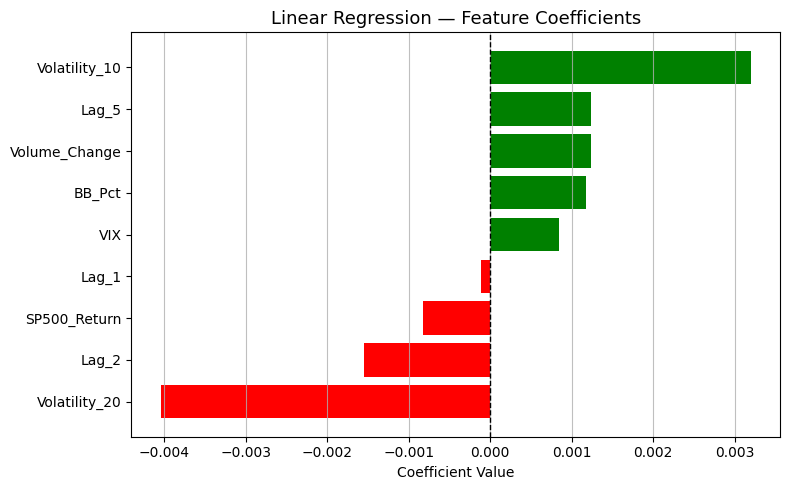

In [126]:
coef_lr = pd.Series(lr.coef_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["red" if c < 0 else "green" for c in coef_lr]
ax.barh(coef_lr.index, coef_lr.values, color=colors)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Linear Regression — Feature Coefficients", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.grid(True, alpha=0.8, axis="x")
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong> Linear Regression Coefficient Plot</strong></summary>
        <p>The coefficient plot reveals that <code>Volatility_10</code> and <code>Volatility_20</code> are the dominant features in opposite direction. Short-term volatility positively predicts next-day returns while medium-term volatility negatively predicts them. Also, <code>Lag_1</code> has a coefficient near zero, confirming that yesterday's return alone has almost no linear predictive power, while the relatively large opposing coefficients on the two volatility features signal multicollinearity,the primary motivation for applying Ridge regularization in the next step.</p>
    </details>
</div>

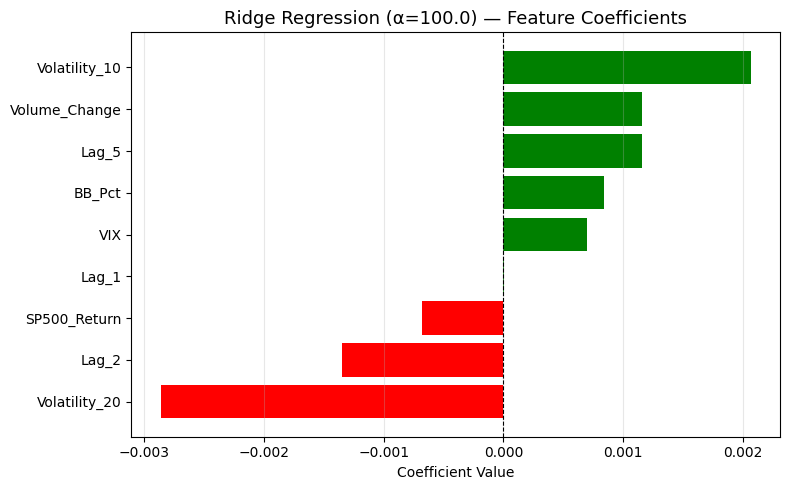

In [127]:
coef_ridge = pd.Series(ridge.coef_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["red" if c < 0 else "green" for c in coef_ridge]
ax.barh(coef_ridge.index, coef_ridge.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Ridge Regression (α={ridge.alpha_}) — Feature Coefficients", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Ridge Regression — Coefficient Plot</strong></summary>
        <p>The coefficient plot for Ridge Regression (α=100) mirrors the direction and ranking of Linear Regression's coefficients, but with all values visibly shrunk toward zero, confirming that regularization is working as intended by reducing the influence of correlated features like <code>Volatility_10</code> and <code>Volatility_20</code> without eliminating any of them entirely.</p>
    </details>
</div>

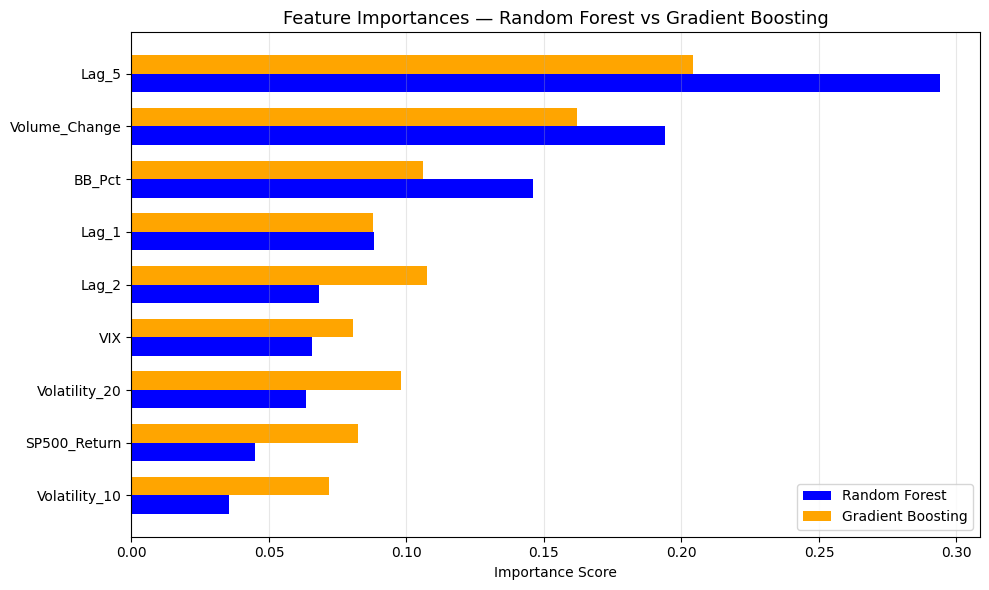

In [128]:
importance_df = pd.DataFrame({
    "Random Forest": best_rf.best_estimator_.feature_importances_,
    "Gradient Boosting": best_gb.best_estimator_.feature_importances_
}, index=features).sort_values("Random Forest", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(features))
width  = 0.35

ax.barh(x - width/2, importance_df["Random Forest"], width, label="Random Forest", color="blue")
ax.barh(x + width/2, importance_df["Gradient Boosting"], width, label="Gradient Boosting", color="orange")

ax.set_yticks(x)
ax.set_yticklabels(importance_df.index)
ax.set_title("Feature Importances — Random Forest vs Gradient Boosting", fontsize=13)
ax.set_xlabel("Importance Score")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Feature Importances — RF vs GB Interpretation</strong></summary>
        <ul>
            <li><code>Lag_5</code> is the top feature in both models (~0.29 RF, ~0.21 GB), suggesting that the 5-day lagged return carries more predictive structure than shorter lags — consistent with weekly momentum patterns in equity markets.</li>
            <li><code>Volume_Change</code> ranks second in both models (~0.19 RF, ~0.16 GB), indicating that relative trading volume provides meaningful signal beyond price-based features alone.</li>
            <li>The two models <strong>broadly agree on the top features</strong> but diverge in the lower ranks — RF assigns very low importance to <code>Volatility_10</code> (~0.04) while GB gives it moderate weight (~0.075). This is consistent with GB's sequential boosting distributing importance more evenly across the feature set.</li>
            <li><code>SP500_Return</code> and <code>Volatility_10</code> rank lowest in RF, suggesting that in a bagging framework, market-wide and short-term volatility features are less discriminative than firm-specific momentum and volume signals.</li>
        </ul>
    </details>
</div>

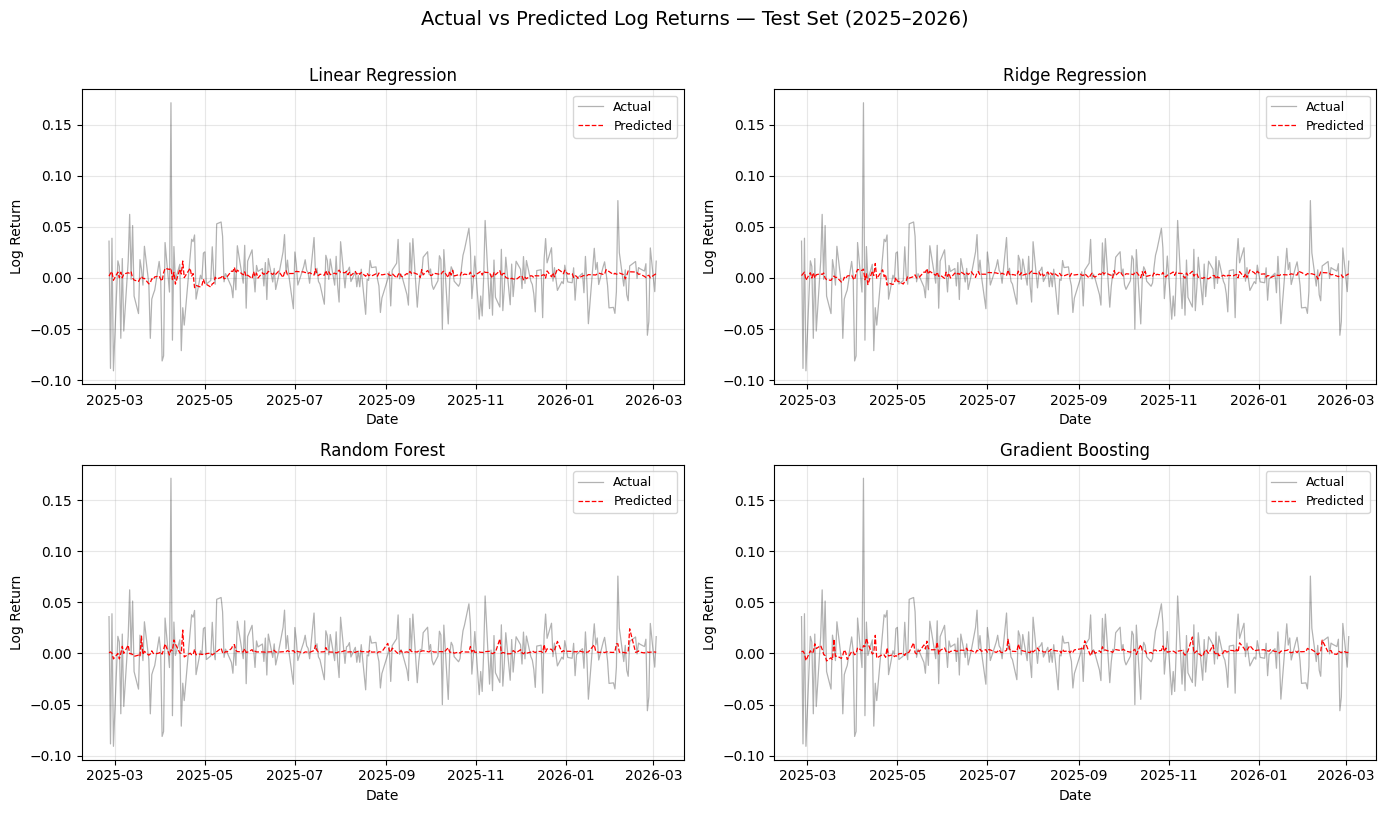

In [129]:
models = {
    "Linear Regression": (lr, X_test_scaled),
    "Ridge Regression": (ridge, X_test_scaled),
    "Random Forest": (best_rf, X_test),
    "Gradient Boosting": (best_gb, X_test),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (name, (model, X_te)) in enumerate(models.items()):
    y_pred = model.predict(X_te)
    axes[i].plot(y_test.index, y_test.values, label="Actual", color="black", linewidth=0.9, alpha=0.3)
    axes[i].plot(y_test.index, y_pred,label="Predicted", color="red", linewidth=0.9, linestyle="--")
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Log Return")
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Actual vs Predicted Log Returns — Test Set (2025–2026)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Actual vs Predicted — Interpretation</strong></summary>
        <ul>
            <li>Across all four models, the predicted line is <strong>nearly flat</strong> throughout the entire test period (Feb 2025 – Mar 2026), while actual returns exhibit sharp and frequent large movements, the most important visual finding of this paper.</li>
            <li>The large spike<strong> in April 2025</strong> is completely missed by every model. This is expected, events and announcements that are entirely absent from the feature set and cannot be anticipated from historical price and volume data alone.</li>
            <li>All four models produce <strong>visually similar predictions</strong>, regardless of their complexity. This demonstrates that the bottleneck is not model capacity but the absence of a learnable signal in the target variable, a finding more informative than any single metric.</li>
            <li>Predictions cluster tightly around zero, which means, the models are effectively predicting the mean of returns, which is the best a model can do under these conditions.</li>
        </ul>
    </details>
</div>

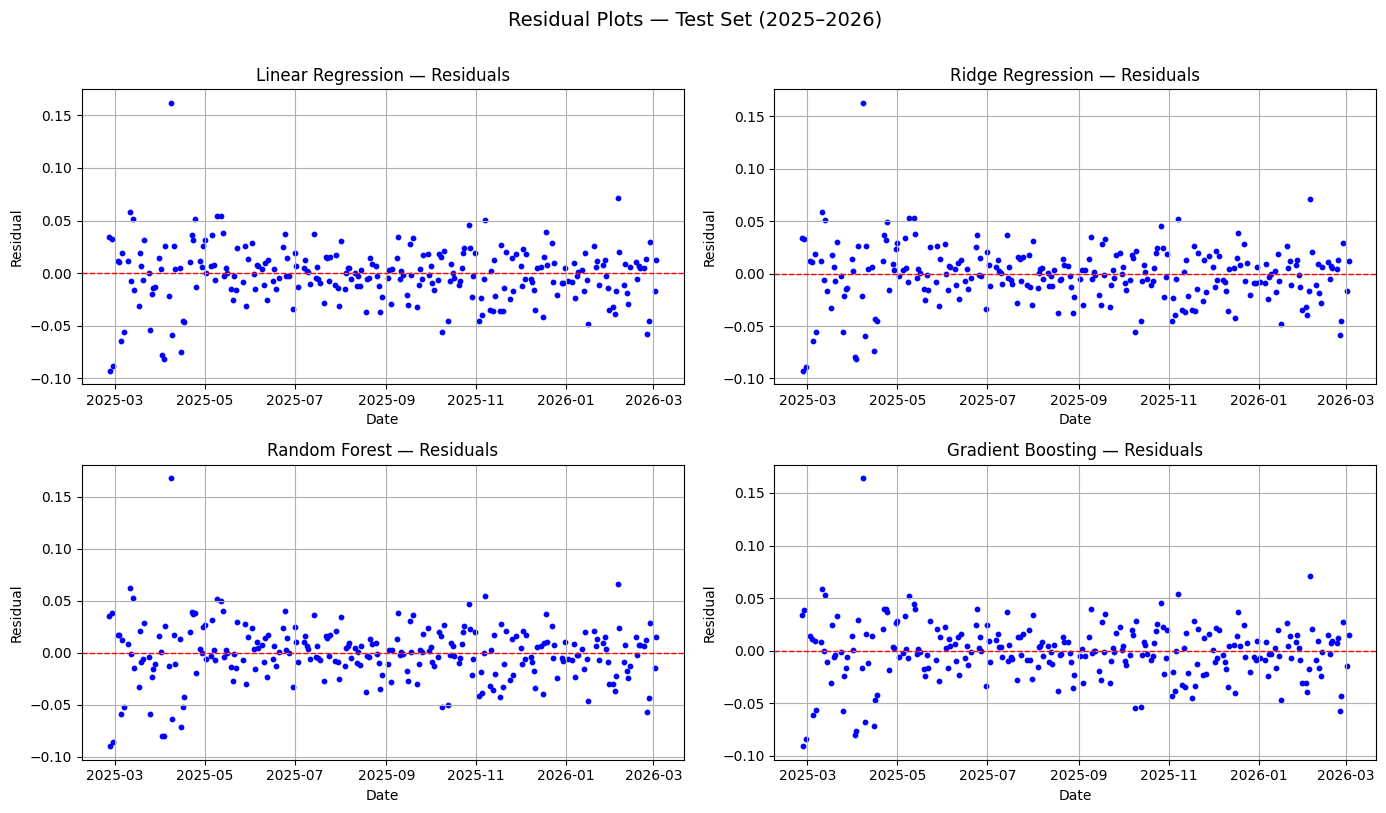

In [130]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (name, (model, X_te)) in enumerate(models.items()):
    residuals = y_test.values - model.predict(X_te)
    axes[i].scatter(y_test.index, residuals, color="blue", s=10)
    axes[i].axhline(0, color="red", linewidth=1, linestyle="--")
    axes[i].set_title(f"{name} — Residuals", fontsize=12)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Residual")
    axes[i].grid(True)

plt.suptitle("Residual Plots — Test Set (2025–2026)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Residual Plots — Interpretation</strong></summary>
        <ul>
            <li>Residuals across all four models scatter <strong>randomly around zero</strong> with no visible upward or downward drift, satisfying the zero conditional mean assumption of regression and indicating no systematic directional bias in any model.</li>
            <li>The spread of residuals is <strong>wider in early 2025</strong> (Feb–May) and narrows toward mid-2025, directly reflecting NVIDIA's actual volatility clustering during the peak AI investment period. This heteroskedasticity is a property of the data, not a model flaw.</li>
            <li>No model shows structured residual patterns (e.g. curves, waves, or clustering by sign), which would indicate missing nonlinear relationships. The random scatter confirms that the features have extracted the available linear and nonlinear signal, what remains is genuine noise.</li>
            <li>The <strong>April 2025 spike</strong> appears as a single large positive residual in all four plots is not captured, confirming it was a news-driven event rather than a predictable pattern.</li>
        </ul>
    </details>
</div>

# Evaliation

In [131]:
results_df = pd.DataFrame(results).set_index("Model")
print("Comparison of Model Performance")
print(results_df.to_string())

Comparison of Model Performance
                                  MAE      RMSE      R²
Model                                                  
Linear Regression            0.019691  0.027641  0.0042
Optimized Ridge              0.019608  0.027573  0.0090
Random Forest Regressor      0.019561  0.027554  0.0104
Gradient Boosting Regressor  0.019375  0.027441  0.0185


<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Model Comparison Table — Interpretation</strong></summary>
        <ul>
            <li>All four models follow the expected progression: <strong>Linear = Ridge -> RF -> GB</strong>, with each step delivering a consistent but modest improvement in MAE, RMSE, and R².</li>
            <li>The <strong>absolute differences are very small</strong>, MAE ranges only from 0.019375 to 0.019691 across all models. In practical terms, this means no model meaningfully outperforms the others in real return prediction, the ranking reflects statistical patterns in the data rather than actionable forecasting power.</li>
            <li><strong>R² values between 0.004 and 0.019</strong> confirm that all models explain less than 2% of next-day return variance. This is not a failure of methodology, it is the expected result for daily stock return prediction and is consistent with the weak form of the Efficient Market Hypothesis.</li>
            <li>The fact that Gradient Boosting (the most complex model) achieves the best score while still producing a near-zero R²,<strong>complexity does not overcome the fundamental unpredictability of short-horizon equity returns.</strong></li>
        </ul>
    </details>
</div>

# Discussion

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Summary, Discussion & Limitations</strong></summary>
        <p>This paper applied four regression models: Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting; to predict next-day log returns of NVIDIA stock using a feature set of 10 technically and economically motivated predictors, including lagged returns, rolling volatility, Bollinger Band percentage, volume change, S&P 500 returns, and VIX. Following a strict chronological 80/20 train-test split and hyperparameter tuning exclusively on training data via <code>RandomizedSearchCV</code> with <code>TimeSeriesSplit</code>, all models were evaluated on an unseen test period spanning February 2025 to March 2026. Results follow the expected complexity progression, Gradient Boosting achieves the best performance (MAE: 0.0194, R²: 0.0185) followed by Random Forest, Ridge, and Linear Regression, but the absolute differences between models are negligible.</p>
        <p>The central finding of this paper is that <strong>no model meaningfully predicts next-day NVIDIA returns</strong>, with all R² values below 0.02 regardless of model complexity. This is not a methodological failure, it is the expected outcome under the weak form of the Efficient Market Hypothesis, which states that past price information cannot reliably predict future returns because any exploitable pattern is quickly arbitraged away. The actual vs predicted plots make this visually unambiguous: all four models produce nearly flat predictions while actual returns exhibit sharp, unpredictable movements driven by news events, earnings surprises, and macroeconomic shocks that are entirely absent from the feature set. The fact that Gradient Boosting, the most sophisticated model, barely outperforms a simple linear baseline reinforces the conclusion that the bottleneck is the absence of signal in the data, not model capacity.</p>
        <p>Several limitations should be acknowledged. First, the feature set relies entirely on historical price and volume data, incorporating alternative data sources such as earnings announcements, analyst sentiment, or news flow could provide genuinely exogenous predictors with stronger signal. Second, the evaluation period (2025–2026) coincides with an unusually volatile regime for NVIDIA driven by AI investment cycles, making out-of-sample performance harder to generalize to calmer market conditions. Finally, while look-ahead bias was carefully avoided through chronological splitting, real-world deployment would face additional frictions, transaction costs, execution latency, and bid-ask spreads — that would further erode any marginal predictive edge, making the practical utility of these models limited beyond their academic purpose.</p>
    </details>
</div>

<div style="background: #d8dbe0; padding: 10px; border-radius: 6px; color: rgb(0, 0, 0); width: 98%">
    <details>
        <summary><strong>Nature of Stock Prices & Volatility Models</strong></summary>
        <p>Stock prices are inherently non-stationary and driven by unpredictable information arrival, making daily return prediction a fundamentally noisy task that no supervised regression model can fully resolve. R² of 0.0185 means Gradient Boosting, the best performing model, explains less than 2% of the variation in next-day NVIDIA returns, with the remaining 98% driven by factors entirely outside the model. This is not a reflection of poor modelling, it is a direct consequence of the nature of daily stock returns, which are dominated by unpredictable news events, earnings surprises, and macroeconomic shocks that leave no traceable pattern in historical price and volume data. The volatility clustering visible in the log returns plot, where periods of large swings are followed by relative calm, is better captured by dedicated time series models: ARIMA models the conditional mean of a return series using its own past values, while ARCH and GARCH models explicitly model the conditional variance, treating volatility itself as the predictable quantity rather than the return direction. These models are outside the scope of this regression task but represent the natural next step for anyone seeking to model NVIDIA's return dynamics more rigorously.</p>
    </details>
</div>